In [1]:
import pandas as pd 
healthcare=pd.read_csv('C:/Users/Ninja\Downloads/Kenya Malaria_Prediction Dataset by who (2).csv')
print(healthcare.head())

   Patient ID  Age  Gender Region Fever Headache Chills Sweats Fatigue  \
0           1   52    Male  Rural   Yes       No    Yes     No     Yes   
1           2   93    Male  Rural   Yes      Yes     No    Yes     Yes   
2           3   15    Male  Rural   Yes      Yes    Yes     No      No   
3           4   72  Female  Urban   Yes       No    Yes     No      No   
4           5   61    Male  Rural    No      Yes    Yes     No      No   

   Hemoglobin (g/dL)  Platelet (cells/μL)  WBC (cells/μL) Parasite Detected  \
0               12.2               367281           10578                No   
1               11.5               261529            6367               Yes   
2               12.5               383009           11904                No   
3               12.7               245800           11793                No   
4               11.6               379350           10677                No   

  Diagnosis  
0  Negative  
1  Negative  
2  Negative  
3  Negative  
4  Negativ

# renaming the columns to remove special characters 

In [2]:
new_columns = {
    'Patient ID': 'patient_id',
    'Age': 'age',
    'Gender': 'gender',
    'Region': 'region',
    'Fever': 'fever',
    'Headache': 'headache',
    'Chills': 'chills',
    'Sweats': 'sweats',
    'Fatigue': 'fatigue',
    'Hemoglobin (g/dL)': 'hb_g_dl',
    'Platelet (cells/µL)': 'platelets_ul',
    'WBC (cells/µL)': 'wbc_ul',
    'Parasite Detected': 'parasite_detected',
    'Diagnosis': 'diagnosis'
}
healthcare.rename(columns=new_columns, inplace=True)
print(healthcare)

      patient_id  age  gender region fever headache chills sweats fatigue  \
0              1   52    Male  Rural   Yes       No    Yes     No     Yes   
1              2   93    Male  Rural   Yes      Yes     No    Yes     Yes   
2              3   15    Male  Rural   Yes      Yes    Yes     No      No   
3              4   72  Female  Urban   Yes       No    Yes     No      No   
4              5   61    Male  Rural    No      Yes    Yes     No      No   
...          ...  ...     ...    ...   ...      ...    ...    ...     ...   
4995        4996   34    Male  Urban   Yes      Yes    Yes    Yes      No   
4996        4997   73  Female  Rural   Yes      Yes     No    Yes      No   
4997        4998   28  Female  Urban    No      Yes    Yes     No      No   
4998        4999   11  Female  Urban   Yes       No     No    Yes      No   
4999        5000   78    Male  Urban   Yes       No     No     No      No   

      hb_g_dl  Platelet (cells/μL)  WBC (cells/μL) parasite_detected diagno

# Handling missing values

In [4]:
# Count missing values per column
healthcare.isnull().sum()

# Percentage of missing values
healthcare.isnull().sum() / len(healthcare) * 100

# Overall summary
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   age                  5000 non-null   int64  
 2   gender               4994 non-null   object 
 3   region               5000 non-null   object 
 4   fever                4997 non-null   object 
 5   headache             4991 non-null   object 
 6   chills               5000 non-null   object 
 7   sweats               5000 non-null   object 
 8   fatigue              5000 non-null   object 
 9   hb_g_dl              5000 non-null   float64
 10  Platelet (cells/μL)  5000 non-null   int64  
 11  WBC (cells/μL)       5000 non-null   int64  
 12  parasite_detected    5000 non-null   object 
 13  diagnosis            5000 non-null   object 
dtypes: float64(1), int64(4), object(9)
memory usage: 547.0+ KB


In [5]:
healthcare.isnull().sum() / len(healthcare) * 100

patient_id             0.00
age                    0.00
gender                 0.12
region                 0.00
fever                  0.06
headache               0.18
chills                 0.00
sweats                 0.00
fatigue                0.00
hb_g_dl                0.00
Platelet (cells/μL)    0.00
WBC (cells/μL)         0.00
parasite_detected      0.00
diagnosis              0.00
dtype: float64

In [6]:
healthcare.isnull().sum()

patient_id             0
age                    0
gender                 6
region                 0
fever                  3
headache               9
chills                 0
sweats                 0
fatigue                0
hb_g_dl                0
Platelet (cells/μL)    0
WBC (cells/μL)         0
parasite_detected      0
diagnosis              0
dtype: int64

In [7]:
# Numerical columns → fill with median
cat_cols = ['gender', 'fever', 'headache']
for col in cat_cols:
    healthcare[col].fillna(healthcare[col].mode()[0], inplace=True)
    print(healthcare.isnull().sum())

patient_id             0
age                    0
gender                 0
region                 0
fever                  3
headache               9
chills                 0
sweats                 0
fatigue                0
hb_g_dl                0
Platelet (cells/μL)    0
WBC (cells/μL)         0
parasite_detected      0
diagnosis              0
dtype: int64
patient_id             0
age                    0
gender                 0
region                 0
fever                  0
headache               9
chills                 0
sweats                 0
fatigue                0
hb_g_dl                0
Platelet (cells/μL)    0
WBC (cells/μL)         0
parasite_detected      0
diagnosis              0
dtype: int64
patient_id             0
age                    0
gender                 0
region                 0
fever                  0
headache               0
chills                 0
sweats                 0
fatigue                0
hb_g_dl                0
Platelet (cells/μL)    0

# Convert Categorical Binary columns to Numeric

In [75]:
# Windows
healthcare.to_excel(r'C:\Users\Ninja\Downloads\healthcare_export.xlsx', index=False)
print(healthcare)

      patient_id  age  gender region fever headache chills sweats fatigue  \
0              1   52    Male  Rural   Yes       No    Yes     No     Yes   
1              2   93    Male  Rural   Yes      Yes     No    Yes     Yes   
2              3   15    Male  Rural   Yes      Yes    Yes     No      No   
3              4   72  Female  Urban   Yes       No    Yes     No      No   
4              5   61    Male  Rural    No      Yes    Yes     No      No   
...          ...  ...     ...    ...   ...      ...    ...    ...     ...   
4995        4996   34    Male  Urban   Yes      Yes    Yes    Yes      No   
4996        4997   73  Female  Rural   Yes      Yes     No    Yes      No   
4997        4998   28  Female  Urban    No      Yes    Yes     No      No   
4998        4999   11  Female  Urban   Yes       No     No    Yes      No   
4999        5000   78    Male  Urban   Yes       No     No     No      No   

      hb_g_dl  Platelet (cells/μL)  WBC (cells/μL) parasite_detected diagno

# Stationarity

In [24]:
# The correlation between patient_id and diagnosis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

In [10]:
healthcare.describe()

,patient_id,age,hb_g_dl,Platelet (cells/μL),WBC (cells/μL),diag_numeric
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,49.398200,12.468400,273417.080000,7941.991600,0.196200
std,1443.520003,28.677471,1.441937,72349.202378,2317.169132,0.397161
min,1.000000,1.000000,10.000000,150002.000000,4002.000000,0.000000
25%,1250.750000,25.000000,11.200000,210426.750000,5951.000000,0.000000
50%,2500.500000,49.000000,12.500000,271639.500000,7908.000000,0.000000
75%,3750.250000,74.000000,13.700000,335890.500000,9932.000000,0.000000
max,5000.000000,99.000000,15.000000,399974.000000,11996.000000,1.000000


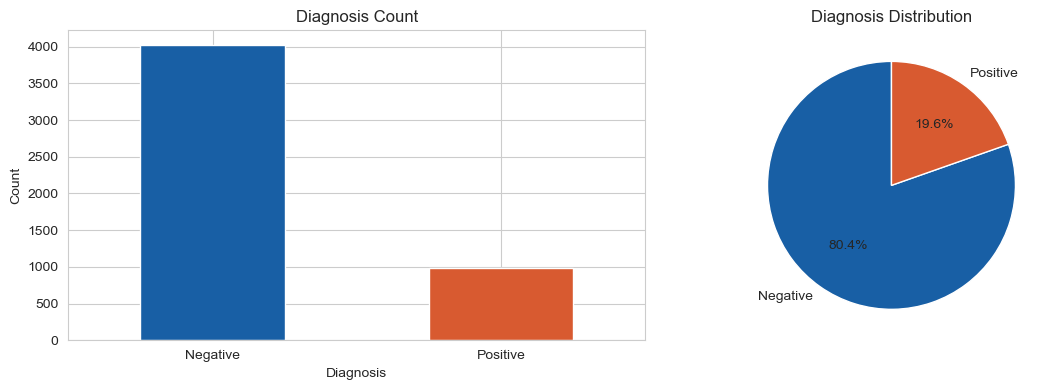

Negative    4019
Positive     981
Name: diagnosis, dtype: int64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
healthcare['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], 
                                             color=['#185FA5','#D85A30'], edgecolor='white')
axes[0].set_title('Diagnosis Count')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
# Percentage pie
healthcare['diagnosis'].value_counts().plot(kind='pie', ax=axes[1],
                                             autopct='%1.1f%%',
                                             colors=['#185FA5','#D85A30'],
                                             startangle=90)
axes[1].set_title('Diagnosis Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(healthcare['diagnosis'].value_counts())

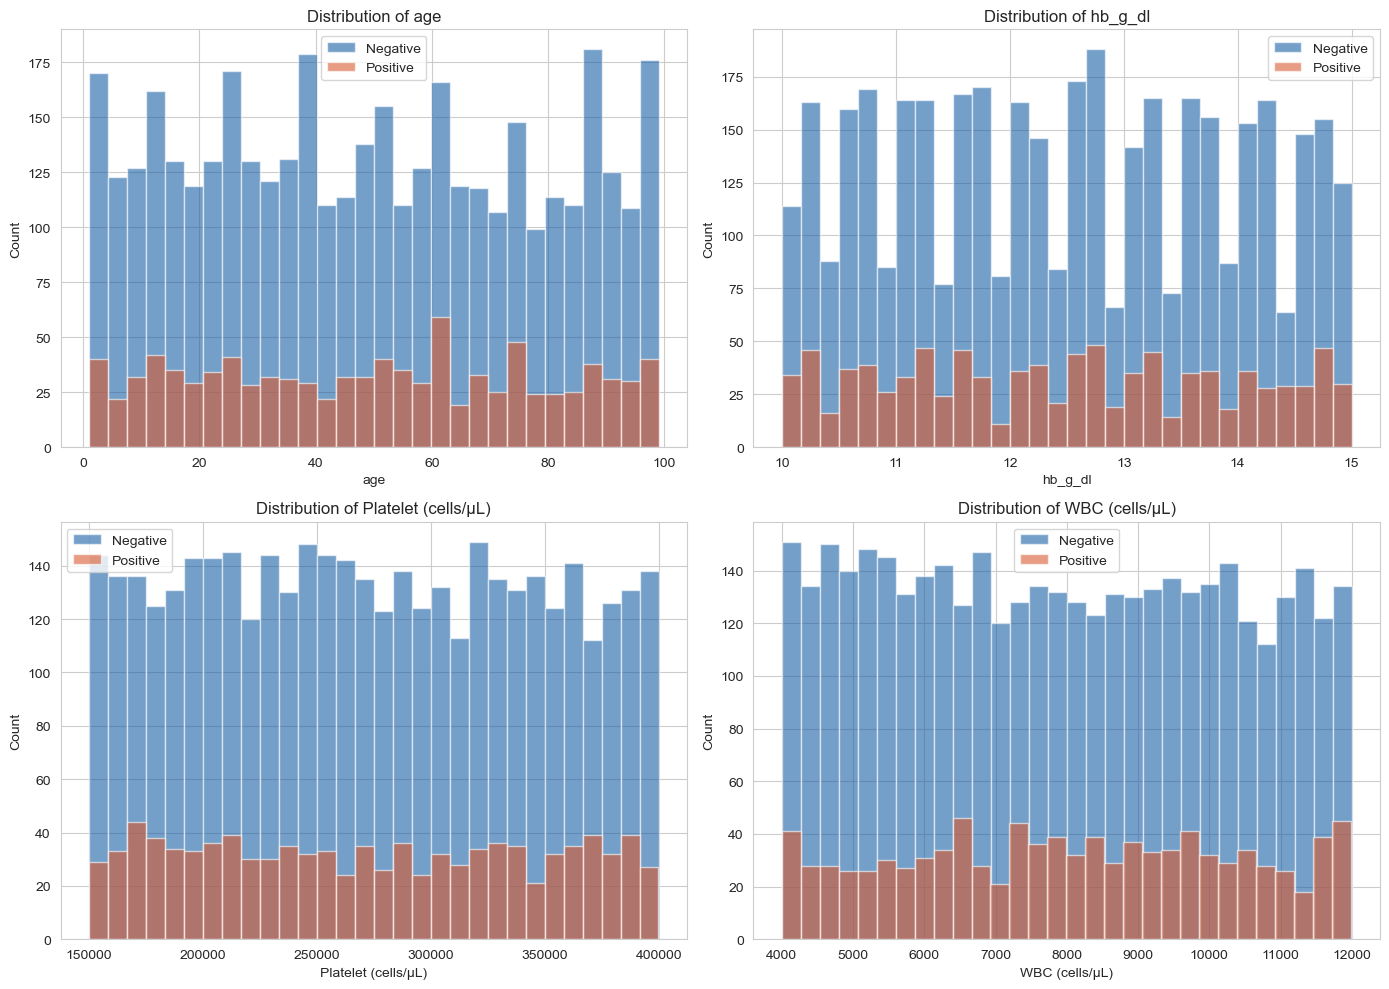

In [16]:
#Numeric feature distributions by diagnosis
numeric_cols = ['age', 'hb_g_dl', 'Platelet (cells/μL)', 'WBC (cells/μL)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(['Negative', 'Positive'], ['#185FA5', '#D85A30']):
        subset = healthcare[healthcare['diagnosis'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.show()

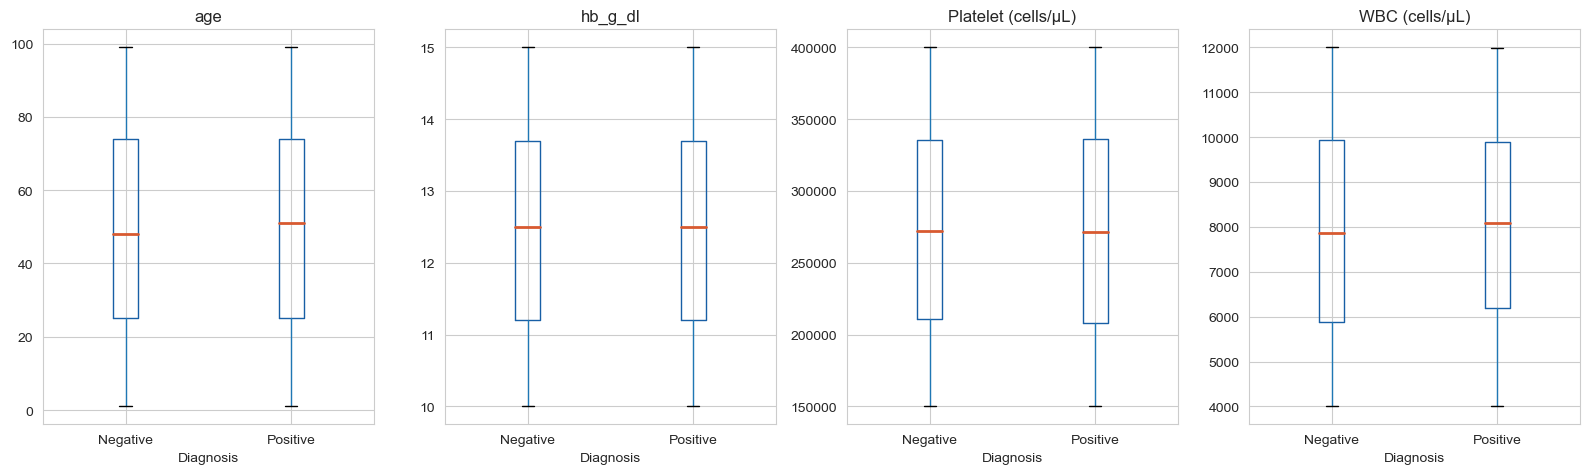

In [17]:
# Boxplots for numeric features
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    healthcare.boxplot(column=col, by='diagnosis', ax=axes[i],
                       boxprops=dict(color='#185FA5'),
                       medianprops=dict(color='#D85A30', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Diagnosis')

plt.suptitle('')
plt.tight_layout()
plt.show()

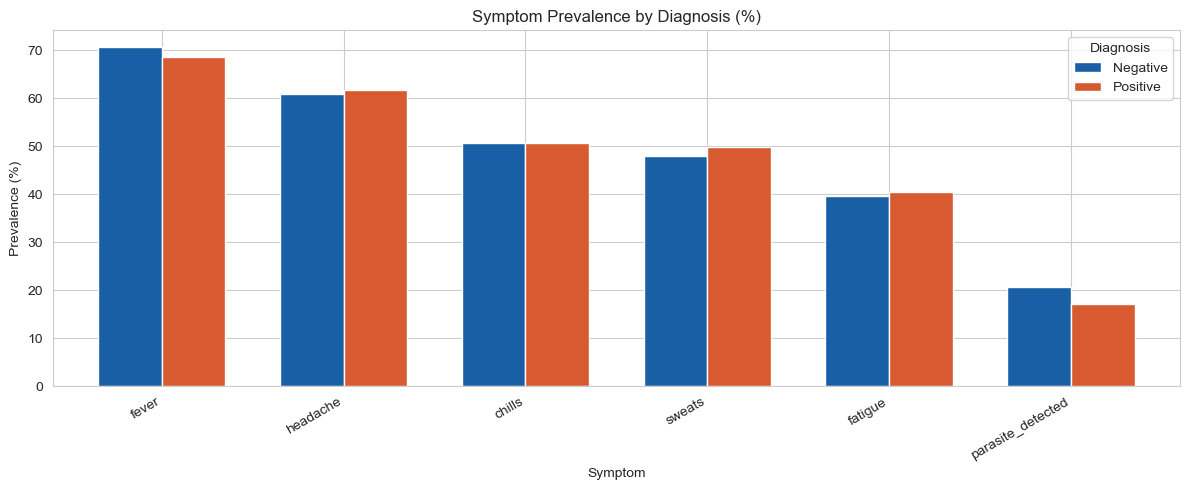

diagnosis          Negative  Positive
fever                  70.6      68.6
headache               60.8      61.7
chills                 50.7      50.7
sweats                 47.9      49.7
fatigue                39.5      40.6
parasite_detected      20.6      17.2


In [18]:
#Symptom prevalence by diagnosis
symptoms = ['fever', 'headache', 'chills', 'sweats', 'fatigue', 'parasite_detected']

symptom_rates = {}
for sym in symptoms:
    rates = healthcare.groupby('diagnosis')[sym].apply(lambda x: (x == 'Yes').mean() * 100)
    symptom_rates[sym] = rates

symptom_df = pd.DataFrame(symptom_rates).T

symptom_df.plot(kind='bar', figsize=(12, 5), 
                color=['#185FA5', '#D85A30'], 
                edgecolor='white', width=0.7)
plt.title('Symptom Prevalence by Diagnosis (%)')
plt.ylabel('Prevalence (%)')
plt.xlabel('Symptom')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

print(symptom_df.round(1))
   

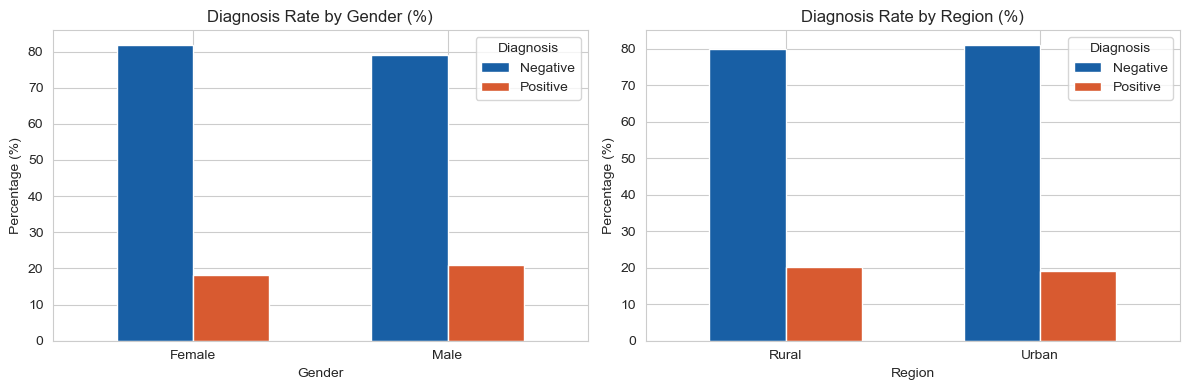

In [19]:
#Categorical features vs diagnosis
cat_cols = ['gender', 'region']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(healthcare[col], healthcare['diagnosis'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#185FA5', '#D85A30'], 
            edgecolor='white', width=0.6)
    axes[i].set_title(f'Diagnosis Rate by {col.title()} (%)')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel(col.title())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Diagnosis')

plt.tight_layout()
plt.show()

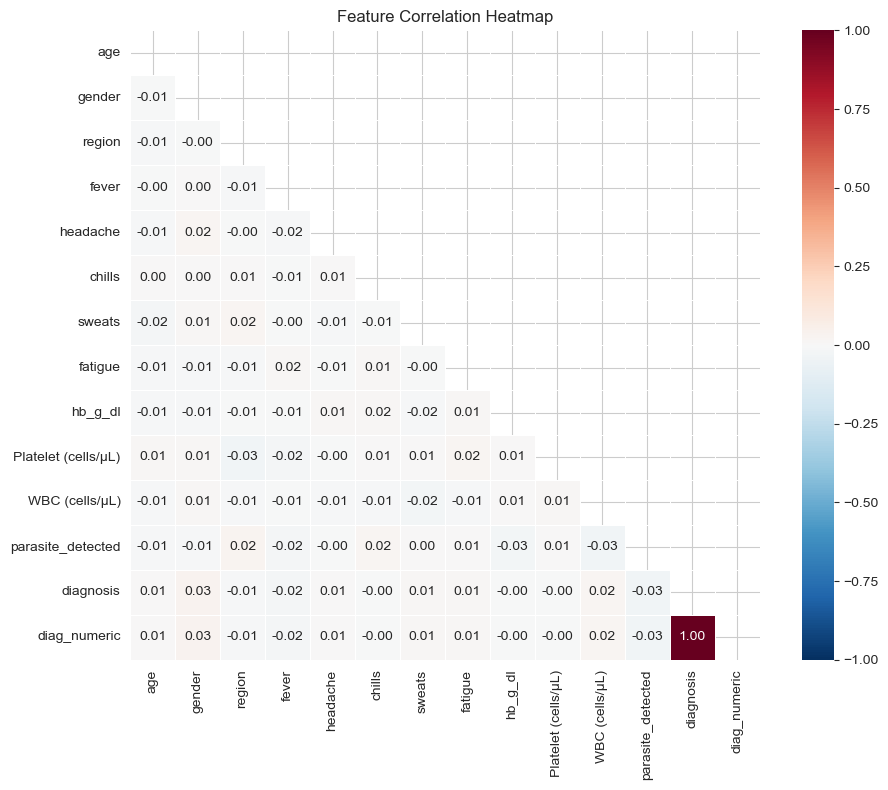

In [26]:
#Correlation heatmap
df_enc = healthcare.copy()

# Encode binary columns
df_enc['diagnosis']        = (healthcare['diagnosis'] == 'Positive').astype(int)
df_enc['gender']           = (healthcare['gender'] == 'Male').astype(int)
df_enc['region']           = (healthcare['region'] == 'Urban').astype(int)
for col in ['fever','headache','chills','sweats','fatigue','parasite_detected']:
    df_enc[col] = (healthcare[col] == 'Yes').astype(int)

df_enc = df_enc.drop('patient_id', axis=1)

plt.figure(figsize=(10, 8))
corr_matrix = df_enc.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

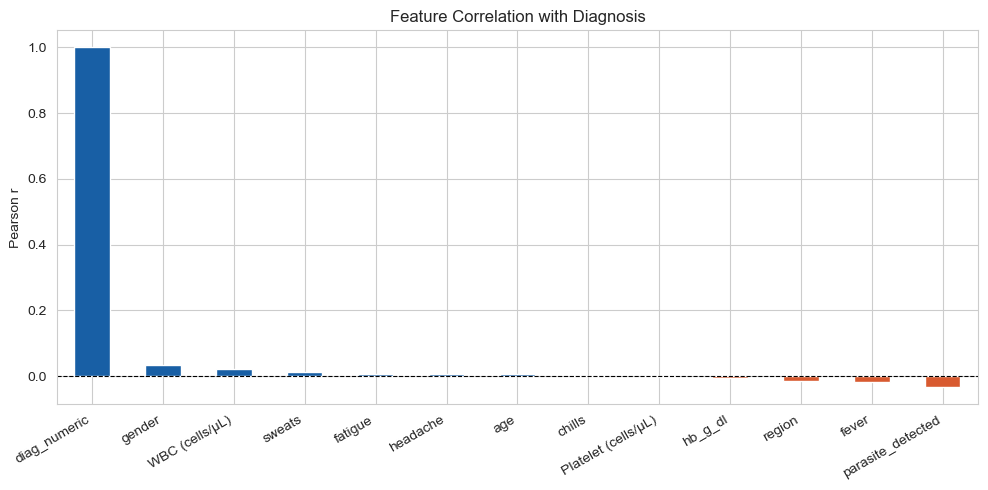

diag_numeric           1.000
gender                 0.035
WBC (cells/μL)         0.022
sweats                 0.014
fatigue                0.008
headache               0.007
age                    0.006
chills                -0.000
Platelet (cells/μL)   -0.002
hb_g_dl               -0.005
region                -0.014
fever                 -0.017
parasite_detected     -0.034
Name: diagnosis, dtype: float64


In [27]:
# Correlation with diagnosis (ranked)
corr_with_target = df_enc.corr()['diagnosis'].drop('diagnosis').sort_values(ascending=False)

colors = ['#185FA5' if v >= 0 else '#D85A30' for v in corr_with_target]

plt.figure(figsize=(10, 5))
corr_with_target.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Diagnosis')
plt.ylabel('Pearson r')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(corr_with_target.round(3))

In [29]:
#EDA summary
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Dataset shape       : {healthcare.shape}")
print(f"Missing values      : {healthcare.isnull().sum().sum()}")
print(f"Duplicate rows      : {healthcare.duplicated().sum()}")
print(f"\nTarget distribution :")
print(healthcare['diagnosis'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f"\nStrongest predictor : {corr_with_target.abs().idxmax()} (r={corr_with_target.abs().max():.3f})")
print(f"Weakest predictor   : {corr_with_target.abs().idxmin()} (r={corr_with_target.abs().min():.3f})")
print("\nKey finding: All correlations are near zero — no strong")
print("individual predictor exists. Feature engineering needed.")

EDA SUMMARY
Dataset shape       : (5000, 15)
Missing values      : 0
Duplicate rows      : 0

Target distribution :
Negative    80.4
Positive    19.6

Strongest predictor : diag_numeric (r=1.000)
Weakest predictor   : chills (r=0.000)

Key finding: All correlations are near zero — no strong
individual predictor exists. Feature engineering needed.
